# CS 513 Final Project - NYPD Vehicle Stop Report Data
## Data Modeling

Name: Samuel Preston and Dean Filippone  
CWID: 10463953 and 20006018  
Assignment: Final Project  
Purpose: Analyze data regarding NYPD Traffic Stops  

##### Imports

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import resample

#models imports
# Naive Bayes
from sklearn.naive_bayes import GaussianNB, CategoricalNB

# ANN (Artificial Neural Network)
from sklearn.neural_network import MLPClassifier

# KNN (K-Nearest Neighbors)
from sklearn.neighbors import KNeighborsClassifier

# CART (Classification and Regression Trees)
from sklearn.tree import DecisionTreeClassifier

# Logistic Regression
from sklearn.linear_model import LogisticRegression

# Random Forest
from sklearn.ensemble import RandomForestClassifier

# SVM
from sklearn.svm import SVC

# Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier

# XGBoost
from xgboost import XGBClassifier

##### Reading Data

In [15]:
df = pd.read_csv("nypd_vehicle_stops_Cleaned.csv")

##### Data Encoding / Train Test Split

In [16]:
# Identify categorical columns for one-hot encoding
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Exclude columns that shouldn't be one-hot encoded (like IDs or datetime strings)
exclude_cols = ['event_id', 'stop_date', 'stop_time', 'stop_datetime']
categorical_cols = [col for col in categorical_cols if col not in exclude_cols]

# One-hot encode remaining categorical columns
df_encoded = df.drop(columns=['stop_date', 'stop_time', 'stop_datetime'])
df_encoded = df_encoded.dropna()
df_encoded = pd.get_dummies(df_encoded, columns=categorical_cols, drop_first=True)

# Display the encoded DataFrame

# Ensure all column names are strings and contain only safe characters
df_encoded.columns = df_encoded.columns.map(lambda col: str(col).replace('[', '').replace(']', '').replace('<', '').replace(' ', '_'))

# Return basic info
df_encoded

# Separate classes
df_majority = df_encoded[df_encoded['arrest_made'] == False]
df_minority = df_encoded[df_encoded['arrest_made'] == True]

# Upsample minority
df_majority_downsampled = resample(
    df_majority,
    replace=False,
    n_samples=len(df_minority),
    random_state=42
)

df_enc_bal = pd.concat([df_majority_downsampled, df_minority])

X = df_enc_bal.drop("arrest_made", axis="columns")
y = df_enc_bal['arrest_made']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)


In [17]:
best_models = {}

### Logistic Regression

Accuracy:  0.5482
Precision: 0.5481
Recall:    0.5964
F1 Score:  0.5712

Classification Report:

              precision    recall  f1-score   support

   No Arrest       0.55      0.50      0.52      5051
 Arrest Made       0.55      0.60      0.57      5146

    accuracy                           0.55     10197
   macro avg       0.55      0.55      0.55     10197
weighted avg       0.55      0.55      0.55     10197



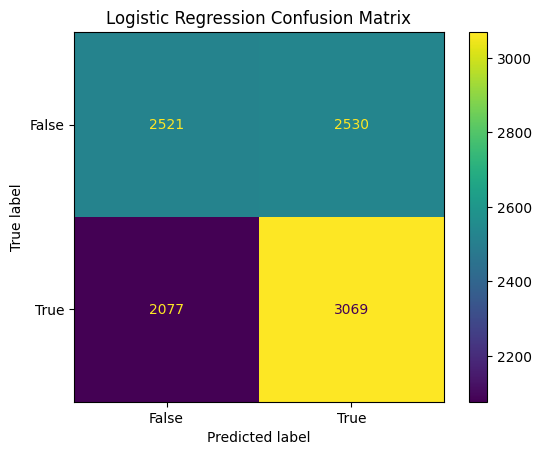

In [18]:
# Train the model
LR_model = LogisticRegression(max_iter=5000, class_weight=None)  # You can change to 'balanced' later
LR_model.fit(X_train, y_train)

# Make predictions
LR_pred = LR_model.predict(X_test)

# Evaluate metrics
LR_acc = accuracy_score(y_test, LR_pred)
LR_precision = precision_score(y_test, LR_pred, zero_division=0)
LR_recall = recall_score(y_test, LR_pred)
LR_f1 = f1_score(y_test, LR_pred)

# Store best model score (can adjust to store more later)
best_models['Logistic Regression'] = LR_acc

# Print metrics
print(f"Accuracy:  {LR_acc:.4f}")
print(f"Precision: {LR_precision:.4f}")
print(f"Recall:    {LR_recall:.4f}")
print(f"F1 Score:  {LR_f1:.4f}")

# Optional: detailed classification report
print("\nClassification Report:\n")
print(classification_report(y_test, LR_pred, target_names=['No Arrest', 'Arrest Made']))

# Confusion Matrix
cm = confusion_matrix(y_test, LR_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LR_model.classes_)
disp.plot()
plt.title('Logistic Regression Confusion Matrix')
plt.show()


### Random Forest Classifier

Accuracy:  0.8126
Precision: 0.7949
Recall:    0.8473
F1 Score:  0.8202

Classification Report:

              precision    recall  f1-score   support

   No Arrest       0.83      0.78      0.80      5051
 Arrest Made       0.79      0.85      0.82      5146

    accuracy                           0.81     10197
   macro avg       0.81      0.81      0.81     10197
weighted avg       0.81      0.81      0.81     10197



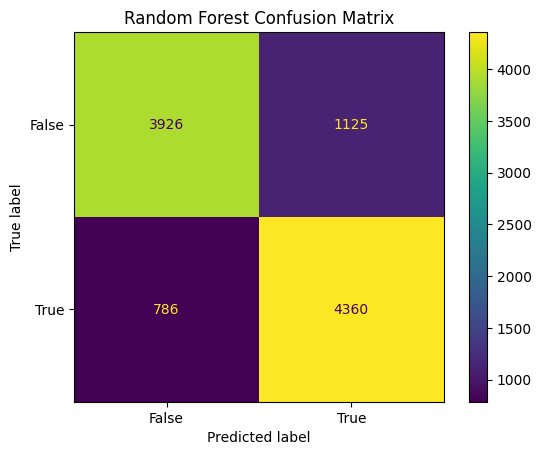

In [19]:
# Train the model
RF_model = RandomForestClassifier(class_weight='balanced', random_state=42)
RF_model.fit(X_train, y_train)

# Make predictions
RF_pred = RF_model.predict(X_test)

# Evaluate metrics
RF_acc = accuracy_score(y_test, RF_pred)
RF_precision = precision_score(y_test, RF_pred, zero_division=0)
RF_recall = recall_score(y_test, RF_pred)
RF_f1 = f1_score(y_test, RF_pred)

# Store best model score (adjust as needed)
best_models['Random Forest'] = RF_acc

# Print metrics
print(f"Accuracy:  {RF_acc:.4f}")
print(f"Precision: {RF_precision:.4f}")
print(f"Recall:    {RF_recall:.4f}")
print(f"F1 Score:  {RF_f1:.4f}")

# Optional: detailed classification report
print("\nClassification Report:\n")
print(classification_report(y_test, RF_pred, target_names=['No Arrest', 'Arrest Made']))

# Confusion Matrix
cm = confusion_matrix(y_test, RF_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=RF_model.classes_)
disp.plot()
plt.title('Random Forest Confusion Matrix')
plt.show()

### X Gradient Boost

/usr/local/lib/python3.10/dist-packages/xgboost/training.py:183: UserWarning: [16:14:21] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy:  0.8167
Precision: 0.7962
Recall:    0.8558
F1 Score:  0.8250

Classification Report:

              precision    recall  f1-score   support

   No Arrest       0.84      0.78      0.81      5051
 Arrest Made       0.80      0.86      0.82      5146

    accuracy                           0.82     10197
   macro avg       0.82      0.82      0.82     10197
weighted avg       0.82      0.82      0.82     10197



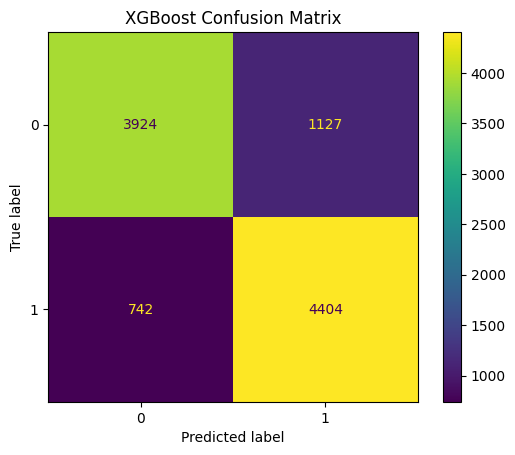

In [20]:
# Calculate class imbalance weight
scale = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# Train the model
XGB_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', scale_pos_weight=scale, random_state=42)
XGB_model.fit(X_train, y_train)

# Make predictions
XGB_pred = XGB_model.predict(X_test)

# Evaluate metrics
XGB_acc = accuracy_score(y_test, XGB_pred)
XGB_precision = precision_score(y_test, XGB_pred, zero_division=0)
XGB_recall = recall_score(y_test, XGB_pred)
XGB_f1 = f1_score(y_test, XGB_pred)

# Store best model score
best_models['XGBoost'] = XGB_acc

# Print metrics
print(f"Accuracy:  {XGB_acc:.4f}")
print(f"Precision: {XGB_precision:.4f}")
print(f"Recall:    {XGB_recall:.4f}")
print(f"F1 Score:  {XGB_f1:.4f}")

# Optional: detailed classification report
print("\nClassification Report:\n")
print(classification_report(y_test, XGB_pred, target_names=['No Arrest', 'Arrest Made']))

# Confusion Matrix
cm = confusion_matrix(y_test, XGB_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=XGB_model.classes_)
disp.plot()
plt.title('XGBoost Confusion Matrix')
plt.show()

### Multi-Layer Perceptron

Accuracy:  0.5047
Precision: 0.5047
Recall:    1.0000
F1 Score:  0.6708

Classification Report:

              precision    recall  f1-score   support

   No Arrest       0.00      0.00      0.00      5051
 Arrest Made       0.50      1.00      0.67      5146

    accuracy                           0.50     10197
   macro avg       0.25      0.50      0.34     10197
weighted avg       0.25      0.50      0.34     10197



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


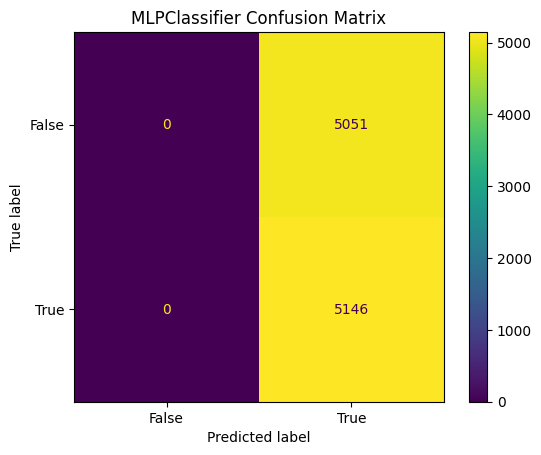

In [21]:
MLP_model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)
MLP_model.fit(X_train, y_train)

MLP_pred = MLP_model.predict(X_test)

MLP_acc = accuracy_score(y_test, MLP_pred)
MLP_precision = precision_score(y_test, MLP_pred, zero_division=0)
MLP_recall = recall_score(y_test, MLP_pred)
MLP_f1 = f1_score(y_test, MLP_pred)

best_models['MLPClassifier'] = MLP_acc

print(f"Accuracy:  {MLP_acc:.4f}")
print(f"Precision: {MLP_precision:.4f}")
print(f"Recall:    {MLP_recall:.4f}")
print(f"F1 Score:  {MLP_f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, MLP_pred, target_names=['No Arrest', 'Arrest Made']))

cm = confusion_matrix(y_test, MLP_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=MLP_model.classes_)
disp.plot()
plt.title('MLPClassifier Confusion Matrix')
plt.show()

### K Nearest Neighbor

Accuracy:  0.5842
Precision: 0.5867
Recall:    0.5958
F1 Score:  0.5912

Classification Report:

              precision    recall  f1-score   support

   No Arrest       0.58      0.57      0.58      5051
 Arrest Made       0.59      0.60      0.59      5146

    accuracy                           0.58     10197
   macro avg       0.58      0.58      0.58     10197
weighted avg       0.58      0.58      0.58     10197



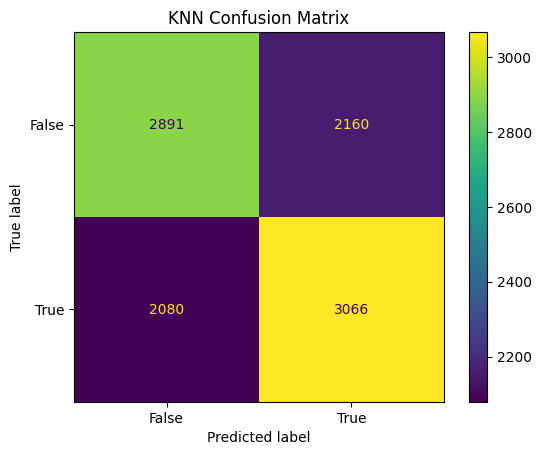

In [22]:
KNN_model = KNeighborsClassifier(n_neighbors=5)
KNN_model.fit(X_train, y_train)

KNN_pred = KNN_model.predict(X_test)

KNN_acc = accuracy_score(y_test, KNN_pred)
KNN_precision = precision_score(y_test, KNN_pred, zero_division=0)
KNN_recall = recall_score(y_test, KNN_pred)
KNN_f1 = f1_score(y_test, KNN_pred)

best_models['KNN'] = KNN_acc

print(f"Accuracy:  {KNN_acc:.4f}")
print(f"Precision: {KNN_precision:.4f}")
print(f"Recall:    {KNN_recall:.4f}")
print(f"F1 Score:  {KNN_f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, KNN_pred, target_names=['No Arrest', 'Arrest Made']))

cm = confusion_matrix(y_test, KNN_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=KNN_model.classes_)
disp.plot()
plt.title('KNN Confusion Matrix')
plt.show()


### Decision Tree Classifier

Accuracy:  0.7419
Precision: 0.7479
Recall:    0.7369
F1 Score:  0.7424

Classification Report:

              precision    recall  f1-score   support

   No Arrest       0.74      0.75      0.74      5051
 Arrest Made       0.75      0.74      0.74      5146

    accuracy                           0.74     10197
   macro avg       0.74      0.74      0.74     10197
weighted avg       0.74      0.74      0.74     10197



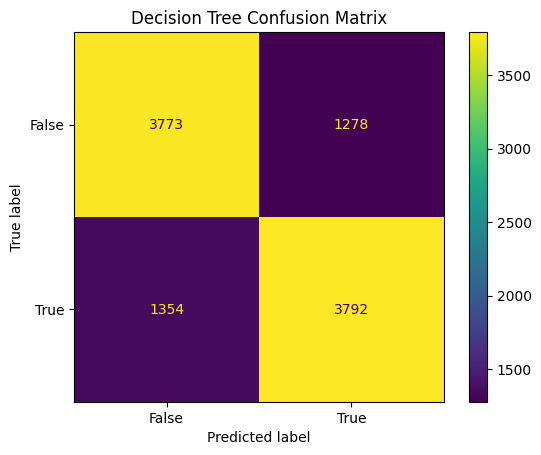

In [23]:
DT_model = DecisionTreeClassifier(class_weight='balanced', random_state=42)
DT_model.fit(X_train, y_train)

DT_pred = DT_model.predict(X_test)

DT_acc = accuracy_score(y_test, DT_pred)
DT_precision = precision_score(y_test, DT_pred, zero_division=0)
DT_recall = recall_score(y_test, DT_pred)
DT_f1 = f1_score(y_test, DT_pred)

best_models['Decision Tree'] = DT_acc

print(f"Accuracy:  {DT_acc:.4f}")
print(f"Precision: {DT_precision:.4f}")
print(f"Recall:    {DT_recall:.4f}")
print(f"F1 Score:  {DT_f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, DT_pred, target_names=['No Arrest', 'Arrest Made']))

cm = confusion_matrix(y_test, DT_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=DT_model.classes_)
disp.plot()
plt.title('Decision Tree Confusion Matrix')
plt.show()


### SVC

Accuracy:  0.5422
Precision: 0.6808
Recall:    0.1749
F1 Score:  0.2783

Classification Report:

              precision    recall  f1-score   support

   No Arrest       0.52      0.92      0.66      5051
 Arrest Made       0.68      0.17      0.28      5146

    accuracy                           0.54     10197
   macro avg       0.60      0.55      0.47     10197
weighted avg       0.60      0.54      0.47     10197



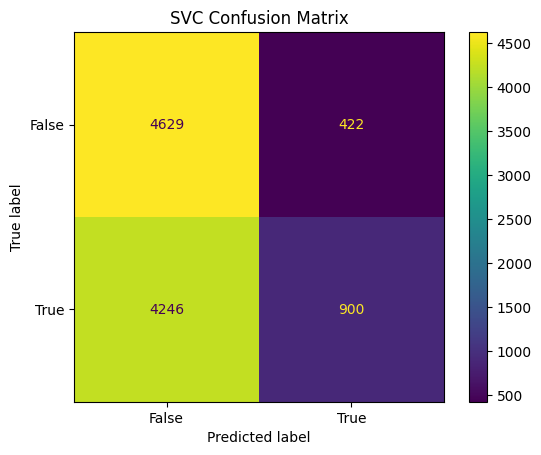

In [24]:
SVC_model = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42)
SVC_model.fit(X_train, y_train)

SVC_pred = SVC_model.predict(X_test)

SVC_acc = accuracy_score(y_test, SVC_pred)
SVC_precision = precision_score(y_test, SVC_pred, zero_division=0)
SVC_recall = recall_score(y_test, SVC_pred)
SVC_f1 = f1_score(y_test, SVC_pred)

best_models['SVC'] = SVC_acc

print(f"Accuracy:  {SVC_acc:.4f}")
print(f"Precision: {SVC_precision:.4f}")
print(f"Recall:    {SVC_recall:.4f}")
print(f"F1 Score:  {SVC_f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, SVC_pred, target_names=['No Arrest', 'Arrest Made']))

cm = confusion_matrix(y_test, SVC_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=SVC_model.classes_)
disp.plot()
plt.title('SVC Confusion Matrix')
plt.show()

### Gradient Boosting

Accuracy:  0.8088
Precision: 0.7810
Recall:    0.8630
F1 Score:  0.8200

Classification Report:

              precision    recall  f1-score   support

   No Arrest       0.84      0.75      0.80      5051
 Arrest Made       0.78      0.86      0.82      5146

    accuracy                           0.81     10197
   macro avg       0.81      0.81      0.81     10197
weighted avg       0.81      0.81      0.81     10197



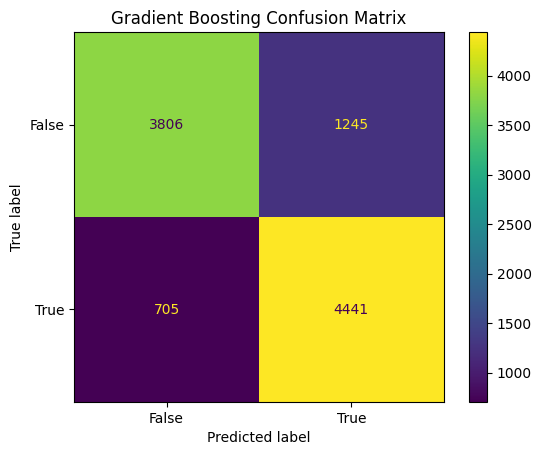

In [25]:
GB_model = GradientBoostingClassifier(random_state=42)
GB_model.fit(X_train, y_train)

GB_pred = GB_model.predict(X_test)

GB_acc = accuracy_score(y_test, GB_pred)
GB_precision = precision_score(y_test, GB_pred, zero_division=0)
GB_recall = recall_score(y_test, GB_pred)
GB_f1 = f1_score(y_test, GB_pred)

best_models['Gradient Boosting'] = GB_acc

print(f"Accuracy:  {GB_acc:.4f}")
print(f"Precision: {GB_precision:.4f}")
print(f"Recall:    {GB_recall:.4f}")
print(f"F1 Score:  {GB_f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, GB_pred, target_names=['No Arrest', 'Arrest Made']))

cm = confusion_matrix(y_test, GB_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=GB_model.classes_)
disp.plot()
plt.title('Gradient Boosting Confusion Matrix')
plt.show()


### Gaussian Naive Bayes

Accuracy:  0.5814
Precision: 0.6094
Recall:    0.4751
F1 Score:  0.5340

Classification Report:

              precision    recall  f1-score   support

   No Arrest       0.56      0.69      0.62      5051
 Arrest Made       0.61      0.48      0.53      5146

    accuracy                           0.58     10197
   macro avg       0.59      0.58      0.58     10197
weighted avg       0.59      0.58      0.58     10197



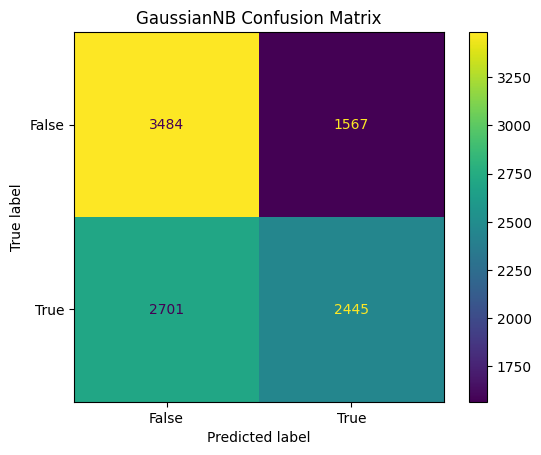

In [26]:
### Gaussian Naive Bayes
GNB_model = GaussianNB()
GNB_model.fit(X_train, y_train)

GNB_pred = GNB_model.predict(X_test)

GNB_acc = accuracy_score(y_test, GNB_pred)
GNB_precision = precision_score(y_test, GNB_pred, zero_division=0)
GNB_recall = recall_score(y_test, GNB_pred)
GNB_f1 = f1_score(y_test, GNB_pred)

best_models['GaussianNB'] = GNB_acc

print(f"Accuracy:  {GNB_acc:.4f}")
print(f"Precision: {GNB_precision:.4f}")
print(f"Recall:    {GNB_recall:.4f}")
print(f"F1 Score:  {GNB_f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, GNB_pred, target_names=['No Arrest', 'Arrest Made']))

cm = confusion_matrix(y_test, GNB_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=GNB_model.classes_)
disp.plot()
plt.title('GaussianNB Confusion Matrix')
plt.show()


### Model Results

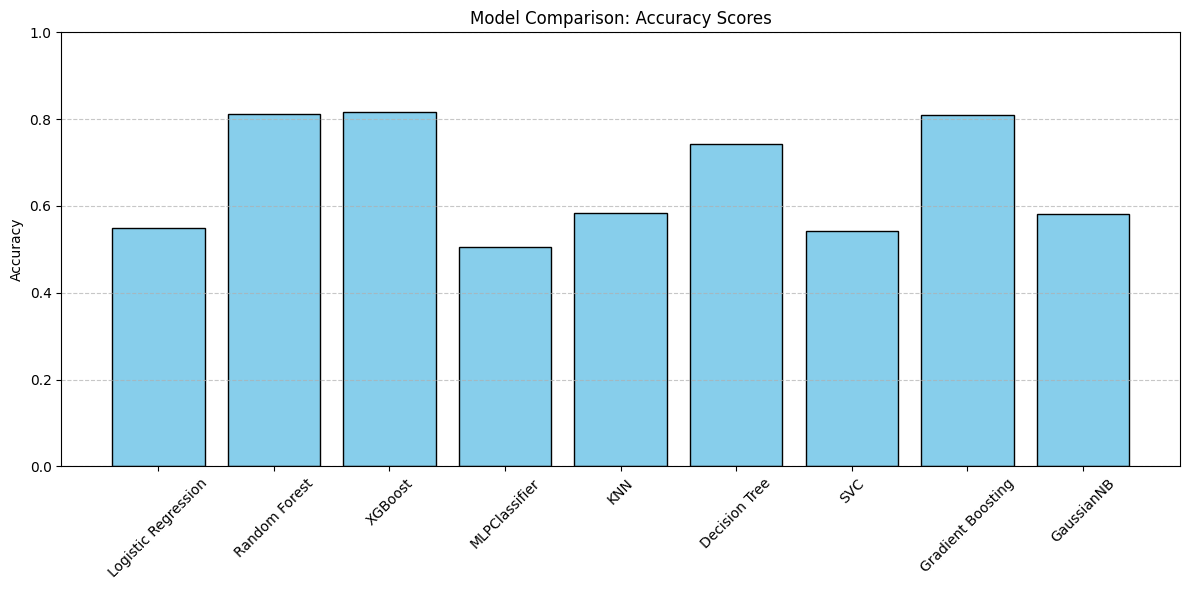

In [27]:
plt.figure(figsize=(12, 6))
plt.bar(best_models.keys(), best_models.values(), color='skyblue', edgecolor='black')
plt.title("Model Comparison: Accuracy Scores")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [28]:
# Sort models by accuracy (descending)
sorted_models = sorted(best_models.items(), key=lambda x: x[1], reverse=True)

print("Model Performance (sorted by accuracy):\n")
for model, acc in sorted_models:
    print(f"{model:<20} Accuracy: {acc:.4f}")


Model Performance (sorted by accuracy):

XGBoost              Accuracy: 0.8167
Random Forest        Accuracy: 0.8126
Gradient Boosting    Accuracy: 0.8088
Decision Tree        Accuracy: 0.7419
KNN                  Accuracy: 0.5842
GaussianNB           Accuracy: 0.5814
Logistic Regression  Accuracy: 0.5482
SVC                  Accuracy: 0.5422
MLPClassifier        Accuracy: 0.5047
